In [1]:
import os
import sys
sys.path.append('/home/royhirsch/conformal/')

from ml_collections import config_dict
import logging
import pandas as pd
import pickle
import torch
import torch.nn as nn

from conformal import get_conformal_module, get_percentile, clip_scores, calibrate_residual
from conformal_baselines import calc_baseline_mets
from data import get_dataloaders
from model import NN
from trainer import Trainer, get_optimizer, get_scheduler
from config import get_config_by_name
import utils as utils


def predict_and_report_mets(conformal_module, trainer, model, dl, fold_name=''):
    predict_out = trainer.predict(model, dl)

    if conformal_module.score_clip_value:
        predict_out['pred_scores'] = clip_scores(
            predict_out['pred_scores'],
            conformal_module.score_clip_value)

    sets = conformal_module.get_sets(predict_out['pred_scores'], predict_out['cls_probs'])
    mets = conformal_module.get_conformal_mets(sets, predict_out['cls_labels'])
    utils.log(f'{fold_name} mets', mets)
    return predict_out, mets

In [2]:
config = get_config_by_name('tissuemnist')
config.use_score_clipping = False
config.val_interval = 2
config.lr = 1e-3
config.wd = 1e-6
config.num_epochs = 50

utils.seed_everything(config.seed)
utils.create_logger(config.exp_dir, config.dump_log)

# logging.info('Config:')
# for k, v in config.items():
#     logging.info(f'{k}: {v}')
# logging.info('')

conformal_module = get_conformal_module(config.conformal_module_name)
dls, t = get_dataloaders(config, conformal_module)


INFO - 11/21/23 18:57:11 - 0:00:00 - Created main log at tmp/net_launcher_log.log
INFO - 11/21/23 18:57:12 - 0:00:00 - Split 47280 samples to train/val/test : 39715/3782/3782
INFO - 11/21/23 18:57:12 - 0:00:00 - train shape: (39715,)
INFO - 11/21/23 18:57:12 - 0:00:00 - valid shape: (3782,)
INFO - 11/21/23 18:57:12 - 0:00:00 - test shape: (3782,)
  2%|▏         | 2/100 [00:01<01:29,  1.10it/s]
INFO - 11/21/23 18:57:15 - 0:00:03 - Temp is 1.2110


In [3]:
class SizesDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset        

    def __getitem__(self, i):
        out = self.dataset.__getitem__(i)
        probs = out['probs'].numpy().tolist()
        score = out['scores'].numpy()
        probs = sorted(probs)[::-1]
        s = 0
        for i, p in enumerate(probs):
            s += p
            if s >= score:
                break
        out['size'] = torch.tensor(i + 1)
        return out

    def __len__(self):
        return len(self.dataset)

train_dl = torch.utils.data.DataLoader(
    SizesDataset(dls['train'].dataset), 
    batch_size=config.batch_size,
    shuffle=True,
    pin_memory=True)


valid_dl = torch.utils.data.DataLoader(
    SizesDataset(dls['valid'].dataset), 
    batch_size=config.batch_size,
    shuffle=False,
    pin_memory=True)


test_dl = torch.utils.data.DataLoader(
    SizesDataset(dls['test'].dataset), 
    batch_size=config.batch_size,
    shuffle=False,
    pin_memory=True)


In [4]:
import numpy as np

class ClsMetricLogger(utils.MetricLogger):
    def __init__(self):
        super().__init__()

    def reset(self):
        self._losses = []
        self._hits = 0
        self._total = 0

    def update(self, pred, true):
        self._hits += sum(pred.argmax(1).detach().cpu().numpy() == true.detach().cpu().numpy())
        self._total += len(true)

    def calc(self):
        return {'loss': np.mean(self._losses),
                'acc': float(self._hits) / self._total}

class ClsTrainer(Trainer):
    def __init__(self, criteria, metric_logger, config):
        super().__init__(criteria, metric_logger, config)

    def get_label(self, batch):
        return batch['size']

    def to_device(self, batch, device=None):
        device = self.config.device if device == None else device
        for k, v in batch.items():
            if isinstance(v, torch.Tensor):
                if k in ['size', 'embeds']:
                    batch[k] = v.to(self.config.device)
        return batch



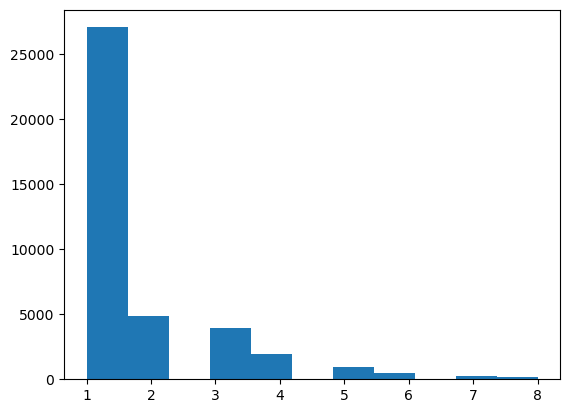

In [5]:
import matplotlib.pyplot as plt
s = []
for i in range(len(train_dl.dataset)):
    s.append(train_dl.dataset.__getitem__(i)['size'])
c = plt.hist(s, bins=11)

In [6]:
w = torch.tensor(c[0])
w /= torch.tensor(c[0]).sum()
w = 1. / (w + 1e-8)
w = w.to(config.device).float()

In [7]:
config = get_config_by_name('tissuemnist')

config.use_score_clipping = False
config.val_interval = 2
config.lr = 1e-3
config.wd = 1e-6
config.num_epochs = 50
config.hidden_dim = 32

In [8]:
model = NN(input_dim=config.input_dim,
            hidden_dim=config.hidden_dim,
            out_dim=11,
            norm=config.norm,
            drop_rate=config.drop_rate,
            criteria_name=config.criteria_name)
model = model.to(config.device)
logging.info(model)

optimizer = get_optimizer(model, config)
scheduler = get_scheduler(optimizer, config)

criteria = nn.CrossEntropyLoss()

trainer = ClsTrainer(criteria=criteria,
                     metric_logger=ClsMetricLogger,
                     config=config)


trainer.fit(model=model,
            train_loader=train_dl,
            test_loader=valid_dl,
            optimizer=optimizer,
            scheduler=scheduler,
            valid_loader=valid_dl)

INFO - 11/21/23 18:57:17 - 0:00:05 - NN(
                                       (layers): Sequential(
                                         (0): Linear(in_features=2048, out_features=32, bias=True)
                                         (1): ReLU()
                                         (2): Linear(in_features=32, out_features=11, bias=True)
                                       )
                                     )
INFO - 11/21/23 18:57:17 - 0:00:05 - Label transform: none
INFO - 11/21/23 18:57:17 - 0:00:05 - Start training for 50 epochs:
INFO - 11/21/23 18:57:17 - 0:00:05 - Number of batches in train epoch: 311
INFO - 11/21/23 18:57:17 - 0:00:05 - E 1/50 |
311it [00:02, 131.87it/s]
INFO - 11/21/23 18:57:19 - 0:00:08 - E1-Train: loss=1.1001 | acc=0.6781
INFO - 11/21/23 18:57:19 - 0:00:08 - E 2/50 |
311it [00:02, 148.56it/s]
INFO - 11/21/23 18:57:21 - 0:00:10 - E2-Train: loss=1.0382 | acc=0.6808
/home/royhirsch/miniconda3/envs/conf/lib/python3.11/site-packages/torch/optim/lr